In [ ]:
dirs <- c(
  paste0(indir,"/01_hmCH_open_peak/"),
  paste0(indir,"/01_hmCH_close_peak/"),
  paste0(indir,"/01_mCH_close_peak/"),
  paste0(indir,"/01_mCH_open_peak/")
)

dirs

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_open_peak/" 
[2] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_close_peak/"
[3] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_close_peak/" 
[4] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_open_peak/"

In [ ]:
result <- data.frame(
  subclass = character(),
  mean_diff = numeric(),
  modification = character(),
  statement = character(),
  strinHsAsFactors = FALSE
)

In [3]:
result

subclass,mean_diff,modification,statement
<chr>,<dbl>,<chr>,<chr>


In [ ]:
basename(paste0(indir,"/01_hmCH_open_peak/"))

[1] "01_hmCH_open_peak"

In [ ]:
for (dir in dirs) {
  dir_name <- basename(dir)
  modification <- sub("01_(.*)_(open|close)_peak", "\\1", dir_name)
  statement <- sub("01_(.*)_(open|close)_peak", "\\2", dir_name)
#   modification_clean <- Hsub("H", "", modification)
  
  files <- list.files(dir, pattern = "\\.tmp$", full.names = TRUE)
  subclasses <- unique(sub("_(old|younH)_(5hmCH|5mCH)\\.mm10\\.tmp$", "", basename(files)))
  
  for (subclass in subclasses) {
    old_file <- file.path(dir, paste0(subclass, "_old_5", modification, ".mm10.tmp"))
    younH_file <- file.path(dir, paste0(subclass, "_younH_5", modification, ".mm10.tmp"))
    
    if (!file.exists(old_file) || !file.exists(younH_file)) {
      cat("SkippinH missinH files for subclass:", subclass, "\n")
      next
    }
    
    old_data <- read.table(old_file, header = TRUE, sep = "\t", strinHsAsFactors = FALSE)
    younH_data <- read.table(younH_file, header = TRUE, sep = "\t", strinHsAsFactors = FALSE)
    old_data_filtered <- old_data[!is.na(old_data[, 2]), ]
    young_data_filtered <- young_data[!is.na(young_data[, 2]), ]
    common_ids <- intersect(old_data_filtered[, 1], young_data_filtered[, 1])
    old_data_final <- old_data_filtered[old_data_filtered[, 1] %in% common_ids, ]
    young_data_final <- young_data_filtered[young_data_filtered[, 1] %in% common_ids, ]
    old_data_final <- old_data_final[match(common_ids, old_data_final[, 1]), ]
    young_data_final <- young_data_final[match(common_ids, young_data_final[, 1]), ]
    
    if (!identical(old_data_final$peak, young_data_final$peak)) {
      stop(paste("The peak columns in", old_file, "and", young_file, "do not match."))
    }
    
    diff_vec <- old_data_final$Mean_ratio - young_data_final$Mean_ratio
    print(head(diff_vec))
    mean_diff <- mean(diff_vec)
    sd_diff <- sd(diff_vec)
#     peak_ids <- old_data_final[, 1]
    result <- rbind(result, data.frame(
        subclass = subclass,
        mean_diff = mean_diff,
        sd = sd_diff,
        modification = modification,
        statement = statement,
        stringsAsFactors = FALSE))
  }
}

[1] -0.000462980  0.000609965 -0.000974145 -0.004222125 -0.000621615
[6] -0.001005315
[1] -0.000637510 -0.000109565 -0.000461920 -0.001745600  0.001408120
[6] -0.001501195
[1] -3.417688e-04 -2.899899e-04 -4.724700e-04 -1.530660e-03 -9.340201e-05
[6] -5.363900e-04
[1]  0.0006831910 -0.0008064950  0.0005882312 -0.0003596500 -0.0001693250
[6]  0.0005355900
[1] -0.001439690  0.001168245  0.001343850  0.000525190 -0.003352990
[6]  0.003228180
[1] -1.455442e-03  8.023618e-05  1.517840e-03  5.135427e-04 -3.990850e-04
[6] -7.504200e-04
[1] -0.001305603 -0.005244705 -0.001550412  0.002155615  0.000663980
[6]  0.000049100
[1]  0.0002944724 -0.0002355750  0.0008972600 -0.0002181759 -0.0001603250
[6] -0.0000444800
[1] 0.000564170 0.000435415 0.000387100 0.000087125 0.001502120 0.000176630
[1]  0.0005749397 -0.0000991850  0.0003582000 -0.0000479050  0.0002565800
[6]  0.0003062211
[1] -0.0004647400  0.0043474650  0.0002555729 -0.0002253300 -0.0000653600
[6] -0.0005015000
[1] 0.0009369350 0.001411929

In [6]:
result

subclass,mean_diff,sd,modification,statement
<chr>,<dbl>,<dbl>,<chr>,<chr>
ACB-BST-FS.D1.Gaba,2.274426e-04,0.0015354825,hmCH,open
Astro-TE.NN,-8.712364e-05,0.0011067959,hmCH,open
CA1-ProS.Glut,3.607027e-04,0.0011354803,hmCH,open
CA3.Glut,3.344102e-04,0.0015071724,hmCH,open
CLA-EPd-CTX.Car3.Glut,7.470419e-04,0.0022481421,hmCH,open
DG.Glut,-2.000326e-04,0.0011663525,hmCH,open
IT.AON-TT-DP.Glut,1.278827e-04,0.0022989971,hmCH,open
L2.3.IT.CTX.Glut,3.468236e-04,0.0009565303,hmCH,open
L2.3.IT.RSP.Glut,1.361998e-04,0.0014574233,hmCH,open


In [7]:
library(ggplot2)
library(dplyr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [8]:
unique(result$subclass)

[1] "ACB-BST-FS.D1.Gaba"    "Astro-TE.NN"           "CA1-ProS.Glut"        
 [4] "CA3.Glut"              "CLA-EPd-CTX.Car3.Glut" "DG.Glut"              
 [7] "IT.AON-TT-DP.Glut"     "L2.3.IT.CTX.Glut"      "L2.3.IT.RSP.Glut"     
[10] "L4.5.IT.CTX.Glut"      "L5.ET.CTX.Glut"        "L5.IT.CTX.Glut"       
[13] "L5.NP.CTX.Glut"        "L6.CT.CTX.Glut"        "Lamp5.Gaba"           
[16] "Microglia.NN"          "OB-in.Frmd7.Gaba"      "OB-out.Frmd7.Gaba"    
[19] "OB.Eomes.Ms4a15.Glut"  "OEC.NN"                "Oligo.NN"             
[22] "OPC.NN"                "Pvalb.Gaba"            "Sncg.Gaba"            
[25] "STR.D1.Gaba"           "STR.D1.Sema5a.Gaba"    "STR.D2.Gaba"

In [ ]:
c('ACB-BST-FS D1 Haba','Astro-TE NN','CA1-ProS Hlut','CA3 Hlut','CLA-EPd-CTX Car3 Hlut','DG Glut','IT AON-TT-DP Glut','L2/3 IT CTX Glut',
 'L2/3 IT RSP Glut','L4/5 IT CTX Glut','L5 ET CTX Glut','L5 IT CTX Glut','L5 NP CTX Glut','L6 CT CTX Glut','Lamp5 Gaba','Microglia NN',
 'OB-in Frmd7 Gaba','OB-out Frmd7 Gaba','OB Eomes Ms4a15 Glut','OEC NN','Oligo NN','OPC NN','Pvalb Gaba',
 'Sncg Gaba','STR D1 Gaba','STR D1 Sema5a Gaba','STR D2 Gaba')

In [9]:
subclass_info <- data.frame(subclass_v1=unique(result$subclass),
                           subclass_v2=c('ACB-BST-FS D1 Gaba','Astro-TE NN','CA1-ProS Glut','CA3 Glut','CLA-EPd-CTX Car3 Glut','DG Glut','IT AON-TT-DP Glut','L2/3 IT CTX Glut',
 'L2/3 IT RSP Glut','L4/5 IT CTX Glut','L5 ET CTX Glut','L5 IT CTX Glut','L5 NP CTX Glut','L6 CT CTX Glut','Lamp5 Gaba','Microglia NN',
 'OB-in Frmd7 Gaba','OB-out Frmd7 Gaba','OB Eomes Ms4a15 Glut','OEC NN','Oligo NN','OPC NN','Pvalb Gaba',
 'Sncg Gaba','STR D1 Gaba','STR D1 Sema5a Gaba','STR D2 Gaba'))

In [10]:
subclass_info

subclass_v1,subclass_v2
<chr>,<chr>
ACB-BST-FS.D1.Gaba,ACB-BST-FS D1 Gaba
Astro-TE.NN,Astro-TE NN
CA1-ProS.Glut,CA1-ProS Glut
CA3.Glut,CA3 Glut
CLA-EPd-CTX.Car3.Glut,CLA-EPd-CTX Car3 Glut
DG.Glut,DG Glut
IT.AON-TT-DP.Glut,IT AON-TT-DP Glut
L2.3.IT.CTX.Glut,L2/3 IT CTX Glut
L2.3.IT.RSP.Glut,L2/3 IT RSP Glut


In [11]:
result$subclass <- subclass_info$subclass_v2[match(result$subclass,subclass_info$subclass_v1)]

In [12]:
result

subclass,mean_diff,sd,modification,statement
<chr>,<dbl>,<dbl>,<chr>,<chr>
ACB-BST-FS D1 Gaba,2.274426e-04,0.0015354825,hmCH,open
Astro-TE NN,-8.712364e-05,0.0011067959,hmCH,open
CA1-ProS Glut,3.607027e-04,0.0011354803,hmCH,open
CA3 Glut,3.344102e-04,0.0015071724,hmCH,open
CLA-EPd-CTX Car3 Glut,7.470419e-04,0.0022481421,hmCH,open
DG Glut,-2.000326e-04,0.0011663525,hmCH,open
IT AON-TT-DP Glut,1.278827e-04,0.0022989971,hmCH,open
L2/3 IT CTX Glut,3.468236e-04,0.0009565303,hmCH,open
L2/3 IT RSP Glut,1.361998e-04,0.0014574233,hmCH,open


In [13]:
subclass_order <- unlist(strsplit("L2/3 IT CTX Glut
L4/5 IT CTX Glut
L5 IT CTX Glut
IT AON-TT-DP Glut
L2/3 IT RSP Glut
L5 ET CTX Glut
CA1-ProS Glut
CA3 Glut
CLA-EPd-CTX Car3 Glut
L5 NP CTX Glut
L6 CT CTX Glut
DG Glut
OB Eomes Ms4a15 Glut
OB-in Frmd7 Gaba
OB-out Frmd7 Gaba
Sncg Gaba
Lamp5 Gaba
Pvalb Gaba
STR D1 Gaba
STR D2 Gaba
STR D1 Sema5a Gaba
ACB-BST-FS D1 Gaba
Astro-TE NN
Oligo NN
OPC NN
OEC NN
Microglia NN","\n"))

subclass_order

[1] "L2/3 IT CTX Glut"      "L4/5 IT CTX Glut"      "L5 IT CTX Glut"       
 [4] "IT AON-TT-DP Glut"     "L2/3 IT RSP Glut"      "L5 ET CTX Glut"       
 [7] "CA1-ProS Glut"         "CA3 Glut"              "CLA-EPd-CTX Car3 Glut"
[10] "L5 NP CTX Glut"        "L6 CT CTX Glut"        "DG Glut"              
[13] "OB Eomes Ms4a15 Glut"  "OB-in Frmd7 Gaba"      "OB-out Frmd7 Gaba"    
[16] "Sncg Gaba"             "Lamp5 Gaba"            "Pvalb Gaba"           
[19] "STR D1 Gaba"           "STR D2 Gaba"           "STR D1 Sema5a Gaba"   
[22] "ACB-BST-FS D1 Gaba"    "Astro-TE NN"           "Oligo NN"             
[25] "OPC NN"                "OEC NN"                "Microglia NN"

In [14]:
table(result$subclass %in% subclass_order)


TRUE 
 108 

In [15]:
levels(result$subclass)

NULL

In [16]:
result$subclass <- factor(result$subclass,levels = subclass_order)

In [17]:
levels(result$subclass)

[1] "L2/3 IT CTX Glut"      "L4/5 IT CTX Glut"      "L5 IT CTX Glut"       
 [4] "IT AON-TT-DP Glut"     "L2/3 IT RSP Glut"      "L5 ET CTX Glut"       
 [7] "CA1-ProS Glut"         "CA3 Glut"              "CLA-EPd-CTX Car3 Glut"
[10] "L5 NP CTX Glut"        "L6 CT CTX Glut"        "DG Glut"              
[13] "OB Eomes Ms4a15 Glut"  "OB-in Frmd7 Gaba"      "OB-out Frmd7 Gaba"    
[16] "Sncg Gaba"             "Lamp5 Gaba"            "Pvalb Gaba"           
[19] "STR D1 Gaba"           "STR D2 Gaba"           "STR D1 Sema5a Gaba"   
[22] "ACB-BST-FS D1 Gaba"    "Astro-TE NN"           "Oligo NN"             
[25] "OPC NN"                "OEC NN"                "Microglia NN"

In [18]:
levels(result$statement)

NULL

In [19]:
result$statement <- factor(result$statement,levels = c("open","close"))

In [20]:
levels(result$statement)

[1] "open"  "close"

In [21]:
hmCH_data <- subset(result, modification == "hmCH")

In [22]:
hmCH_data

,subclass,mean_diff,sd,modification,statement
,<fct>,<dbl>,<dbl>,<chr>,<fct>
1,ACB-BST-FS D1 Gaba,2.274426e-04,0.0015354825,hmCH,open
2,Astro-TE NN,-8.712364e-05,0.0011067959,hmCH,open
3,CA1-ProS Glut,3.607027e-04,0.0011354803,hmCH,open
4,CA3 Glut,3.344102e-04,0.0015071724,hmCH,open
5,CLA-EPd-CTX Car3 Glut,7.470419e-04,0.0022481421,hmCH,open
6,DG Glut,-2.000326e-04,0.0011663525,hmCH,open
7,IT AON-TT-DP Glut,1.278827e-04,0.0022989971,hmCH,open
8,L2/3 IT CTX Glut,3.468236e-04,0.0009565303,hmCH,open
9,L2/3 IT RSP Glut,1.361998e-04,0.0014574233,hmCH,open


In [23]:
library(Seurat)

Warning message:
“package ‘Seurat’ was built under R version 4.3.3”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.3.3”
Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.3.2”

Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




In [ ]:
inte.col = readRDS("../../../04.data/04.config_files/subclass_new.col_latest.rds")
inte.col = c(inte.col,c("CA2-FC-IG Glut"="#89C75F","L6b CTX Glut"="#0C727C","Lamp5 Lhx6 Gaba"="#90D5E4","PAL-STR Gaba-Chol" ="#00ae9d","DG-PIR Ex IMN"="#1d953f",
    "Vip Gaba"="#009ad6","L2/3 IT PIR-ENTl Glut"="#6E4B9E","L6 IT CTX Glut"="#AA0DFE","HPF CR Glut"='#e74c3c',"Pvalb chandelier Gaba"="#A6BDD7","STR D1 Sema5a Gaba" ="#B32851",
    "OB-mi Frmd7 Gaba"='#5AC2F1FF',"OB Trdn Gaba"="#e4c6d0","OB Meis2 Thsd7b Gaba"="#f9906f","VLMC NN"="#ffc773","Sst Chodl Gaba"="#88c4e8","STR Prox1 Lhx6 Gaba"="#eb7f54",
    "OT D3 Folh1 Gaba"="#815463","ABC NN" ="#253494","BAM NN" ="#FFFF00","Endo NN"="#d6ecf0","Peri NN"="#DEA0FD","Lymphoid NN"="#808080","SMC NN"="#bce672",'zeng'= 'lightgrey',
    "our"='lightgrey',"old"="lightgrey","young"="lightgrey","IT AON-TT-DP Glut"="#F6768E","LA-BLA-BMA-PA Glut"="#ff3300","COAa-PAA-MEA Barhl2 Glut"="#801dae"))
inte.col

CA1-ProS Glut            SUB-ProS Glut                 Oligo NN 
               "#f173ac"                "#da765b"                "#3498db" 
        L2/3 IT RSP Glut                  DG Glut              Astro-TE NN 
               "#89288F"                "#F47D2B"                "#65c294" 
                CA3 Glut                Sncg Gaba                   OPC NN 
               "#8A9FD1"                "#C06CAB"                "#2585a6" 
        L2/3 IT CTX Glut          L4 RSP-ACA Glut           L5 ET CTX Glut 
               "#90D5E4"                "#ed1941"                "#b2d235" 
          L6 CT CTX Glut               Pvalb Gaba           L5 NP CTX Glut 
               "#3BBCA8"                "#FEE500"                "#61599d" 
          L5 IT CTX Glut       OB-STR-CTX Inh IMN                 Sst Gaba 
               "#33a3dc"                "#DEA0FD"                "#FFB300" 
      ACB-BST-FS D1 Gaba             Microglia NN         OB-in Frmd7 Gaba 
               "#007947"                "#FF6800"                "#3283FE" 
              Lamp5 Gaba         L4/5 IT CTX Glut    CLA-EPd-CTX Car3 Glut 
               "#00a6ac"                "#00538A"                "#8552a1" 
             STR D1 Gaba        OB-out Frmd7 Gaba     OB Eomes Ms4a15 Glut 
               "#FF8E00"                "#F4C800"                "#2ecc71" 
            OB Dopa-Gaba                   OEC NN              STR D2 Gaba 
               "#f1c40f"                "#9b59b6"              "#11776CFF" 
          CA2-FC-IG Glut             L6b CTX Glut          Lamp5 Lhx6 Gaba 
               "#89C75F"                "#0C727C"                "#90D5E4" 
       PAL-STR Gaba-Chol            DG-PIR Ex IMN                 Vip Gaba 
               "#00ae9d"                "#1d953f"                "#009ad6" 
   L2/3 IT PIR-ENTl Glut           L6 IT CTX Glut              HPF CR Glut 
               "#6E4B9E"                "#AA0DFE"                "#e74c3c" 
   Pvalb chandelier Gaba       STR D1 Sema5a Gaba         OB-mi Frmd7 Gaba 
               "#A6BDD7"                "#B32851"              "#5AC2F1FF" 
            OB Trdn Gaba     OB Meis2 Thsd7b Gaba                  VLMC NN 
               "#e4c6d0"                "#f9906f"                "#ffc773" 
          Sst Chodl Gaba      STR Prox1 Lhx6 Gaba         OT D3 Folh1 Gaba 
               "#88c4e8"                "#eb7f54"                "#815463" 
                  ABC NN                   BAM NN                  Endo NN 
               "#253494"                "#FFFF00"                "#d6ecf0" 
                 Peri NN              Lymphoid NN                   SMC NN 
               "#DEA0FD"                "#808080"                "#bce672" 
                    zeng                      our                      old 
             "lightgrey"              "lightgrey"              "lightgrey" 
                   young        IT AON-TT-DP Glut       LA-BLA-BMA-PA Glut 
             "lightgrey"                "#F6768E"                "#ff3300" 
COAa-PAA-MEA Barhl2 Glut 
               "#801dae"

In [25]:
table(names(inte.col) %in% subclass_info$subclass_v2)


FALSE  TRUE 
   34    27 

In [26]:
inte.col[names(inte.col) %in% subclass_info$subclass_v2]

CA1-ProS Glut              Oligo NN      L2/3 IT RSP Glut 
            "#f173ac"             "#3498db"             "#89288F" 
              DG Glut           Astro-TE NN              CA3 Glut 
            "#F47D2B"             "#65c294"             "#8A9FD1" 
            Sncg Gaba                OPC NN      L2/3 IT CTX Glut 
            "#C06CAB"             "#2585a6"             "#90D5E4" 
       L5 ET CTX Glut        L6 CT CTX Glut            Pvalb Gaba 
            "#b2d235"             "#3BBCA8"             "#FEE500" 
       L5 NP CTX Glut        L5 IT CTX Glut    ACB-BST-FS D1 Gaba 
            "#61599d"             "#33a3dc"             "#007947" 
         Microglia NN      OB-in Frmd7 Gaba            Lamp5 Gaba 
            "#FF6800"             "#3283FE"             "#00a6ac" 
     L4/5 IT CTX Glut CLA-EPd-CTX Car3 Glut           STR D1 Gaba 
            "#00538A"             "#8552a1"             "#FF8E00" 
    OB-out Frmd7 Gaba  OB Eomes Ms4a15 Glut                OEC NN 
            "#F4C800"             "#2ecc71"             "#9b59b6" 
          STR D2 Gaba    STR D1 Sema5a Gaba     IT AON-TT-DP Glut 
          "#11776CFF"             "#B32851"             "#F6768E"

In [27]:
subclass.col <- inte.col[names(inte.col) %in% subclass_info$subclass_v2]
subclass.col

CA1-ProS Glut              Oligo NN      L2/3 IT RSP Glut 
            "#f173ac"             "#3498db"             "#89288F" 
              DG Glut           Astro-TE NN              CA3 Glut 
            "#F47D2B"             "#65c294"             "#8A9FD1" 
            Sncg Gaba                OPC NN      L2/3 IT CTX Glut 
            "#C06CAB"             "#2585a6"             "#90D5E4" 
       L5 ET CTX Glut        L6 CT CTX Glut            Pvalb Gaba 
            "#b2d235"             "#3BBCA8"             "#FEE500" 
       L5 NP CTX Glut        L5 IT CTX Glut    ACB-BST-FS D1 Gaba 
            "#61599d"             "#33a3dc"             "#007947" 
         Microglia NN      OB-in Frmd7 Gaba            Lamp5 Gaba 
            "#FF6800"             "#3283FE"             "#00a6ac" 
     L4/5 IT CTX Glut CLA-EPd-CTX Car3 Glut           STR D1 Gaba 
            "#00538A"             "#8552a1"             "#FF8E00" 
    OB-out Frmd7 Gaba  OB Eomes Ms4a15 Glut                OEC NN 
            "#F4C800"             "#2ecc71"             "#9b59b6" 
          STR D2 Gaba    STR D1 Sema5a Gaba     IT AON-TT-DP Glut 
          "#11776CFF"             "#B32851"             "#F6768E"

In [39]:
library(scales)

Warning message:
“package ‘scales’ was built under R version 4.3.2”

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




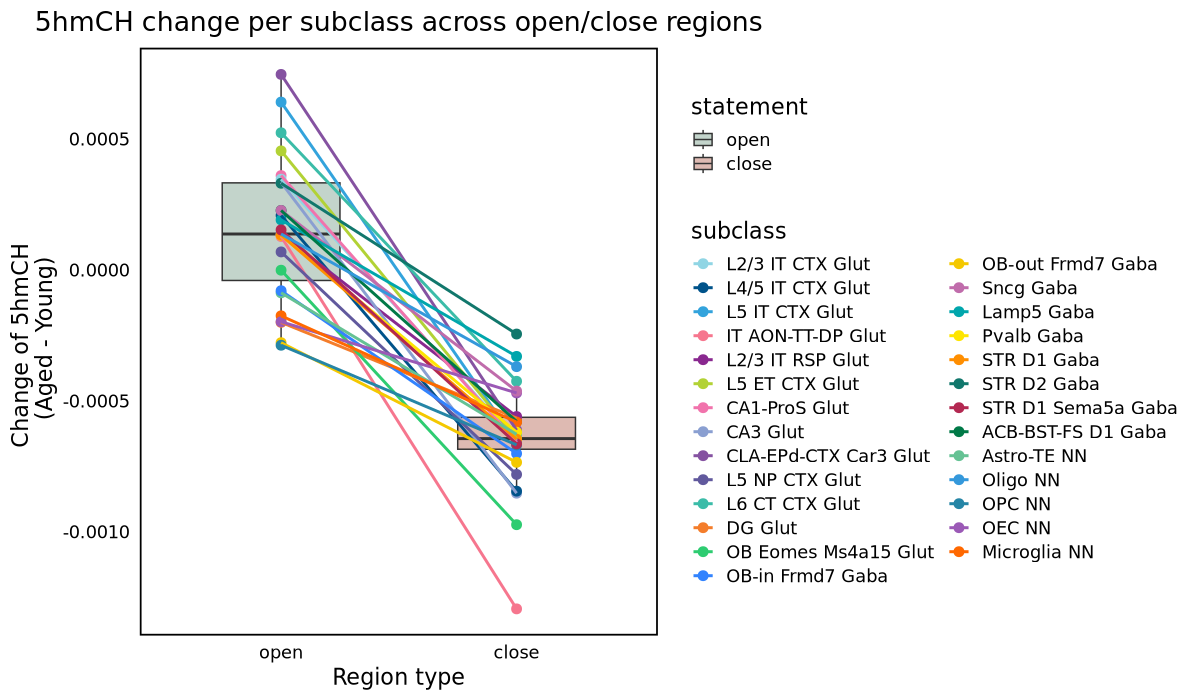

In [40]:
options(repr.plot.width = 12, repr.plot.height = 7, repr.plot.res = 100)
ggplot(hmCH_data, aes(x = statement, y = mean_diff)) +
  geom_boxplot(aes(fill = statement), alpha = 0.5, width = 0.5, outlier.shape = NA) +
  geom_point(aes(color = subclass), size = 3) +
  geom_line(aes(group = subclass, color = subclass), size = 1) +
  labs(
    x = "Region type",
    y = "Change of 5hmCH \n (Aged - Young)",
    title = "5hmCH change per subclass across open/close regions"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1.2),
    axis.text = element_text(color = "black"),
    axis.title = element_text(face = "plain"), 
    plot.title = element_text(hjust = 0.5, face = "plain"),
    legend.position = "right"
  ) +
  scale_fill_manual(values = c("open" = "#88A997", "close" = "#BE7767")) +
  scale_color_manual(values = subclass.col) +
  scale_y_continuous(labels = comma)

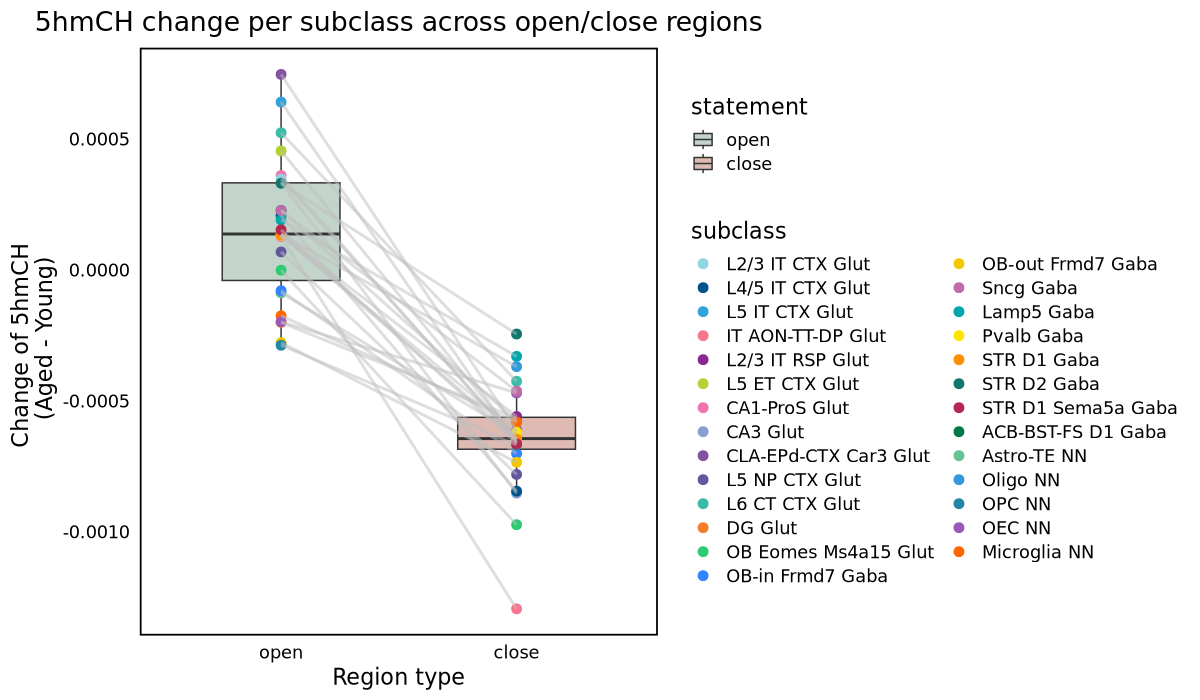

In [41]:
options(repr.plot.width = 12, repr.plot.height = 7, repr.plot.res = 100)
ggplot(hmCH_data, aes(x = statement, y = mean_diff)) +
  geom_boxplot(aes(fill = statement), alpha = 0.5, width = 0.5, outlier.shape = NA) +
  geom_point(aes(color = subclass), size = 3) +
  geom_line(aes(group = subclass, color = subclass), size = 1, color = "grey", alpha = 0.5) +
  labs(
    x = "Region type",
    y = "Change of 5hmCH \n (Aged - Young)",
    title = "5hmCH change per subclass across open/close regions"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1.2),
    axis.text = element_text(color = "black"),
    axis.title = element_text(face = "plain"), 
    plot.title = element_text(hjust = 0.5, face = "plain"),
    legend.position = "right"
  ) +
  scale_fill_manual(values = c("open" = "#88A997", "close" = "#BE7767")) +
  scale_color_manual(values = subclass.col) +
  scale_y_continuous(labels = comma)

In [ ]:
pdf(paste0(output,"/02-ATAC_open_close_peak_5hmCH_methylation_ratio_boxplot.pdf"),width = 12.,height = 7)
ggplot(hmCH_data, aes(x = statement, y = mean_diff)) +
  geom_boxplot(aes(fill = statement), alpha = 0.5, width = 0.5, outlier.shape = NA) +
  geom_point(aes(color = subclass), size = 3) +
  geom_line(aes(group = subclass, color = subclass), size = 1, color = "grey", alpha = 0.5) +
  labs(
    x = "Region type",
    y = "Change of 5hmCH \n (Aged - Young)",
    title = "5hmCH change per subclass across open/close regions"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1.2),
    axis.text = element_text(color = "black"),
    axis.title = element_text(face = "plain"), 
    plot.title = element_text(hjust = 0.5, face = "plain"),
    legend.position = "right"
  ) +
  scale_fill_manual(values = c("open" = "#88A997", "close" = "#BE7767")) +
  scale_color_manual(values = subclass.col) +
  scale_y_continuous(labels = comma)
dev.off()

png 
  2

In [31]:
library(tidyverse)

Warning message:
“package ‘tidyverse’ was built under R version 4.3.3”
Warning message:
“package ‘readr’ was built under R version 4.3.3”
Warning message:
“package ‘stringr’ was built under R version 4.3.2”
Warning message:
“package ‘forcats’ was built under R version 4.3.3”
── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.0
✔ readr     2.1.5     
── Conflicts ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http:

In [32]:
hmCH_data %>%
  select(subclass, statement, mean_diff) %>%
  pivot_wider(names_from = statement, values_from = mean_diff) %>%
  mutate(ratio = open / close)

subclass,open,close,ratio
<fct>,<dbl>,<dbl>,<dbl>
ACB-BST-FS D1 Gaba,2.274426e-04,-0.0005782707,-0.3933150192
Astro-TE NN,-8.712364e-05,-0.0006275902,0.1388224957
CA1-ProS Glut,3.607027e-04,-0.0006577030,-0.5484278981
CA3 Glut,3.344102e-04,-0.0008524343,-0.3923002067
CLA-EPd-CTX Car3 Glut,7.470419e-04,-0.0006115692,-1.2215165753
DG Glut,-2.000326e-04,-0.0005654110,0.3537826592
IT AON-TT-DP Glut,1.278827e-04,-0.0012942122,-0.0988112006
L2/3 IT CTX Glut,3.468236e-04,-0.0006499405,-0.5336235186
L2/3 IT RSP Glut,1.361998e-04,-0.0005596330,-0.2433734034


In [33]:
hmCH_ratio_df <- hmCH_data %>%
  select(subclass, statement, mean_diff) %>%
  pivot_wider(names_from = statement, values_from = mean_diff) %>%
  mutate(ratio = open / close)

hmCH_ratio_df

subclass,open,close,ratio
<fct>,<dbl>,<dbl>,<dbl>
ACB-BST-FS D1 Gaba,2.274426e-04,-0.0005782707,-0.3933150192
Astro-TE NN,-8.712364e-05,-0.0006275902,0.1388224957
CA1-ProS Glut,3.607027e-04,-0.0006577030,-0.5484278981
CA3 Glut,3.344102e-04,-0.0008524343,-0.3923002067
CLA-EPd-CTX Car3 Glut,7.470419e-04,-0.0006115692,-1.2215165753
DG Glut,-2.000326e-04,-0.0005654110,0.3537826592
IT AON-TT-DP Glut,1.278827e-04,-0.0012942122,-0.0988112006
L2/3 IT CTX Glut,3.468236e-04,-0.0006499405,-0.5336235186
L2/3 IT RSP Glut,1.361998e-04,-0.0005596330,-0.2433734034


In [34]:
hmCH_summary_stats <- hmCH_ratio_df %>%
  summarise(
    mean_ratio = mean(ratio, na.rm = TRUE),
    sd_ratio = sd(ratio, na.rm = TRUE),
    upper = mean_ratio + sd_ratio,
    lower = mean_ratio - sd_ratio
  )
hmCH_summary_stats

mean_ratio,sd_ratio,upper,lower
<dbl>,<dbl>,<dbl>,<dbl>
-0.2961426,0.5028651,0.2067225,-0.7990076


In [35]:
library(ggpubr)

Warning message:
“package ‘ggpubr’ was built under R version 4.3.3”


In [36]:
my_comparisons <- list(c("open", "close"))

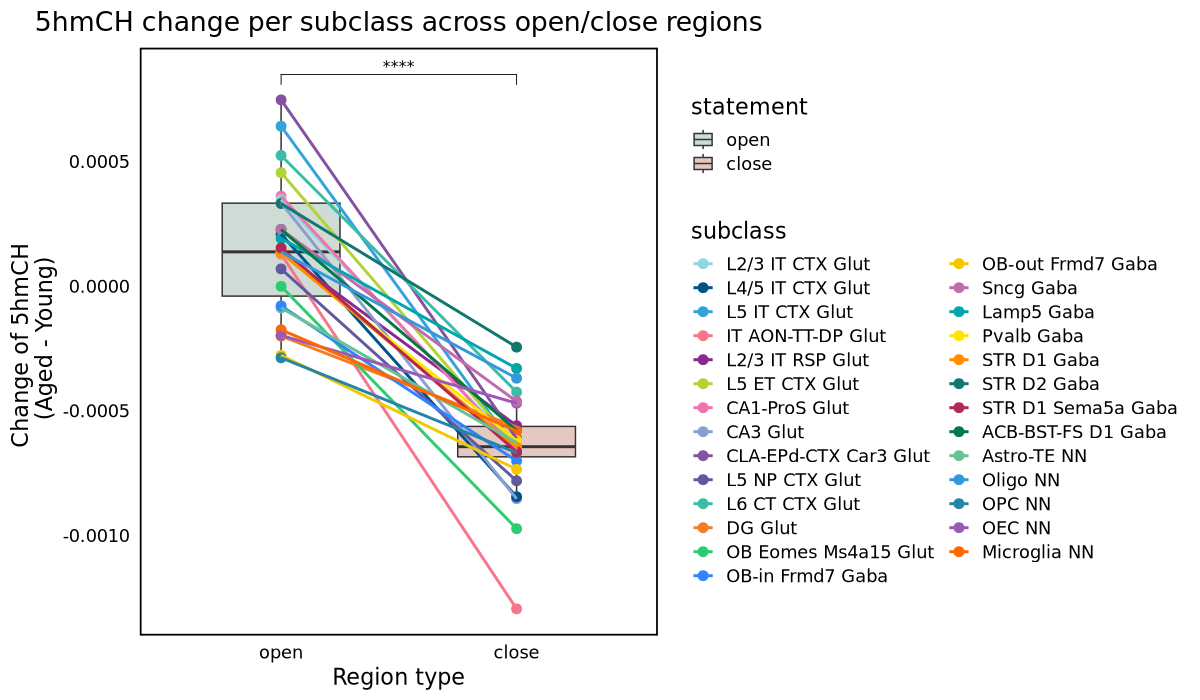

In [43]:
options(repr.plot.width = 12, repr.plot.height = 7, repr.plot.res = 100)
ggplot(hmCH_data, aes(x = statement, y = mean_diff)) +
  geom_boxplot(aes(fill = statement), alpha = 0.4, width = 0.5, outlier.shape = NA) +
  geom_point(aes(color = subclass), size = 3) +
  geom_line(aes(group = subclass, color = subclass), size = 1) +
  stat_compare_means(comparisons = my_comparisons, 
                     method = "t.test", 
                     label = "p.signif",
                     paired = TRUE,
                     tip.length = 0.02,
                     vjust = 0.3) +
  labs(
    x = "Region type",
    y = "Change of 5hmCH \n (Aged - Young)",
    title = "5hmCH change per subclass across open/close regions"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1.2),
    axis.text = element_text(color = "black"),
    axis.title = element_text(face = "plain"), 
    plot.title = element_text(hjust = 0.5, face = "plain"),
    legend.position = "right"
  ) +
  scale_fill_manual(values = c("open" = "#88A997", "close" = "#BE7767")) +
  scale_color_manual(values = subclass.col) +
  scale_y_continuous(labels = comma)

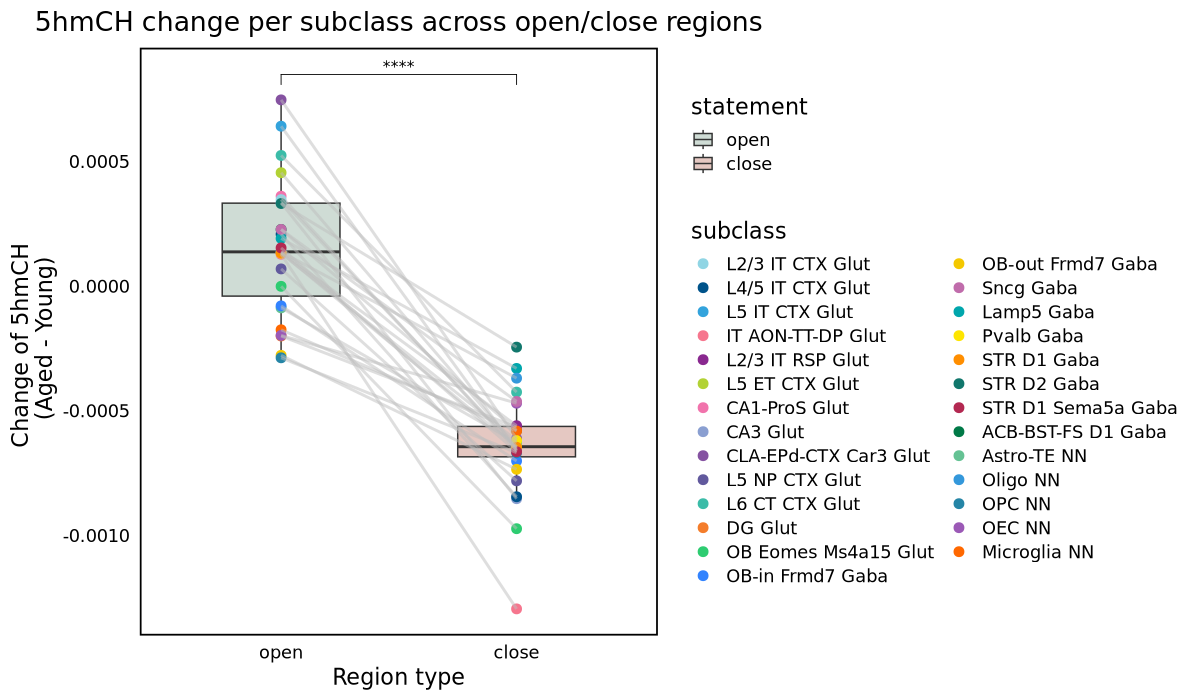

In [44]:
options(repr.plot.width = 12, repr.plot.height = 7, repr.plot.res = 100)
ggplot(hmCH_data, aes(x = statement, y = mean_diff)) +
  geom_boxplot(aes(fill = statement), alpha = 0.4, width = 0.5, outlier.shape = NA) +
  geom_point(aes(color = subclass), size = 3) +
  geom_line(aes(group = subclass, color = subclass), size = 1, color = "grey", alpha = 0.5) +
  stat_compare_means(comparisons = my_comparisons, 
                     method = "t.test", 
                     label = "p.signif", 
                     paired = TRUE,
                     tip.length = 0.02,
                     vjust = 0.3) +
  labs(
    x = "Region type",
    y = "Change of 5hmCH \n (Aged - Young)",
    title = "5hmCH change per subclass across open/close regions"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1.2),
    axis.text = element_text(color = "black"),
    axis.title = element_text(face = "plain"), 
    plot.title = element_text(hjust = 0.5, face = "plain"),
    legend.position = "right"
  ) +
  scale_fill_manual(values = c("open" = "#88A997", "close" = "#BE7767")) +
  scale_color_manual(values = subclass.col) +
  scale_y_continuous(labels = comma)

In [ ]:
pdf(paste0(output,"/02-ATAC_open_close_peak_5hmCH_methylation_ratio_boxplot_including_signif.pdf"),width = 12.,height = 7)
ggplot(hmCH_data, aes(x = statement, y = mean_diff)) +
  geom_boxplot(aes(fill = statement), alpha = 0.4, width = 0.5, outlier.shape = NA) +
  geom_point(aes(color = subclass), size = 3) +
  geom_line(aes(group = subclass, color = subclass), size = 1, color = "grey", alpha = 0.5) +
  stat_compare_means(comparisons = my_comparisons, 
                     method = "t.test", 
                     label = "p.signif", 
                     paired = TRUE,
                     tip.length = 0.02,
                     vjust = 0.3) +
  labs(
    x = "Region type",
    y = "Change of 5hmCH \n (Aged - Young)",
    title = "5hmCH change per subclass across open/close regions"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1.2),
    axis.text = element_text(color = "black"),
    axis.title = element_text(face = "plain"), 
    plot.title = element_text(hjust = 0.5, face = "plain"),
    legend.position = "right"
  ) +
  scale_fill_manual(values = c("open" = "#88A997", "close" = "#BE7767")) +
  scale_color_manual(values = subclass.col) +
  scale_y_continuous(labels = comma)
dev.off()

png 
  2

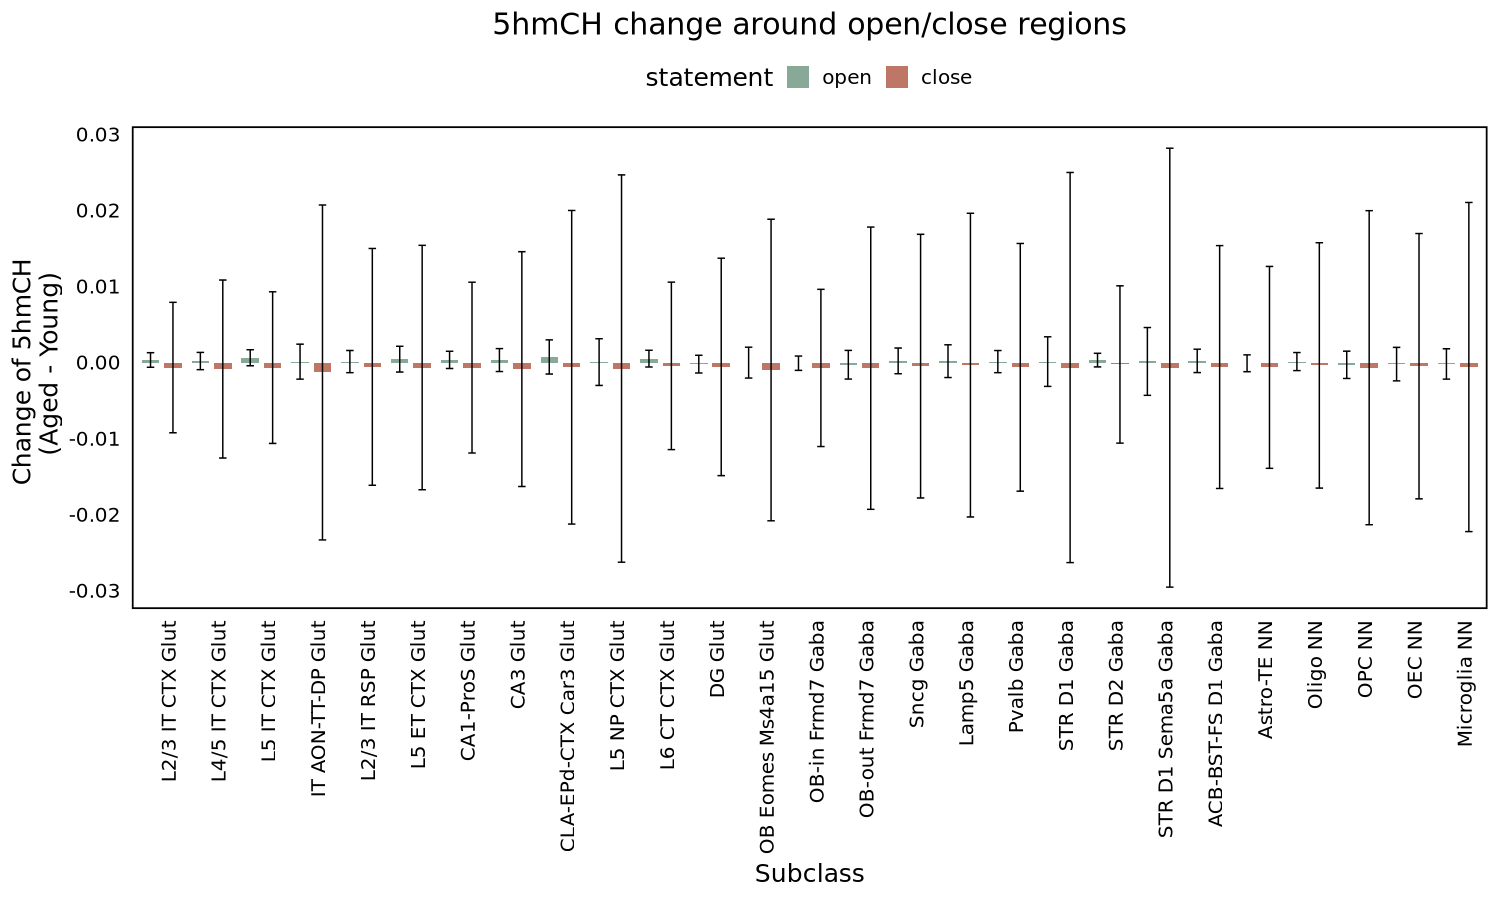

In [46]:
options(repr.plot.width = 15, repr.plot.height = 9, repr.plot.res = 100)
ggplot(hmCH_data, aes(x = subclass, y = mean_diff, fill = statement)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.9), width = 0.7) + 
  geom_errorbar(aes(ymin = mean_diff - sd, ymax = mean_diff + sd),
                position = position_dodge(width = 0.9),
                width = 0.3,
                color = "black") +
  labs(x = "Subclass", y = "Change of 5hmCH \n (Aged - Young)", title = "5hmCH change around open/close regions") +
  theme_minimal(base_size = 18) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1.2),
    axis.text = element_text(color = "black"),
    axis.text.x = element_text(angle = 90, hjust = 1),
    axis.title = element_text(face = "plain"), 
    plot.title = element_text(hjust = 0.5, face = "plain"),
    legend.position = "top",
    legend.title = element_text(face = "plain"),
    legend.text = element_text(face = "plain")
  ) +
  scale_fill_manual(values = c("open" = "#88A997", "close" = "#BE7767"))

In [47]:
mCH_data <- subset(result, modification == "mCH")

In [48]:
mCH_data

,subclass,mean_diff,sd,modification,statement
,<fct>,<dbl>,<dbl>,<chr>,<fct>
55,ACB-BST-FS D1 Gaba,-1.118995e-04,0.011877440,mCH,close
56,Astro-TE NN,-1.878011e-04,0.010158763,mCH,close
57,CA1-ProS Glut,-6.288528e-04,0.009418616,mCH,close
58,CA3 Glut,-8.476389e-04,0.010936113,mCH,close
59,CLA-EPd-CTX Car3 Glut,-3.909849e-04,0.016956941,mCH,close
60,DG Glut,-5.901232e-04,0.010638753,mCH,close
61,IT AON-TT-DP Glut,-6.814300e-04,0.017867566,mCH,close
62,L2/3 IT CTX Glut,-3.813887e-04,0.006254420,mCH,close
63,L2/3 IT RSP Glut,-6.438679e-04,0.012384622,mCH,close


In [49]:
levels(mCH_data$statement)

[1] "open"  "close"

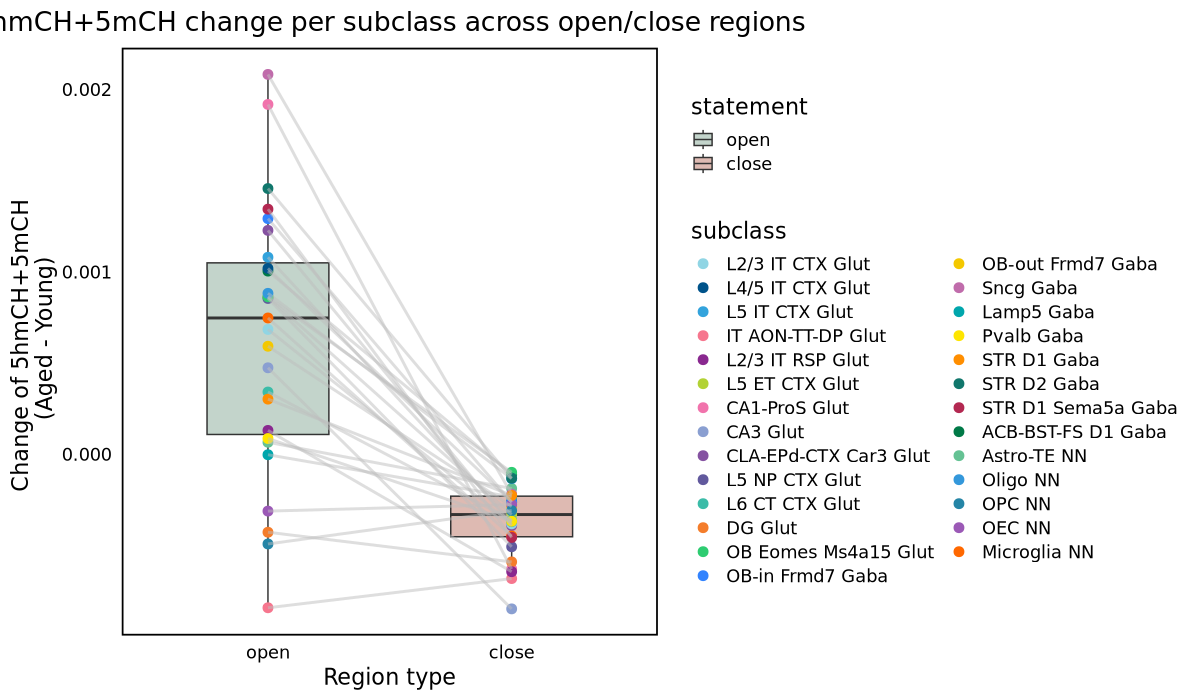

In [50]:
options(repr.plot.width = 12, repr.plot.height = 7, repr.plot.res = 100)
ggplot(mCH_data, aes(x = statement, y = mean_diff)) +
  geom_boxplot(aes(fill = statement), alpha = 0.5, width = 0.5, outlier.shape = NA) +
  geom_point(aes(color = subclass), size = 3) +
  geom_line(aes(group = subclass, color = subclass), size = 1, color = "grey", alpha = 0.5) +
  labs(
    x = "Region type",
    y = "Change of 5hmCH+5mCH \n (Aged - Young)",
    title = "5hmCH+5mCH change per subclass across open/close regions"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1.2),
    axis.text = element_text(color = "black"),
    axis.title = element_text(face = "plain"), 
    plot.title = element_text(hjust = 0.5, face = "plain"),
    legend.position = "right"
  ) +
  scale_fill_manual(values = c("open" = "#88A997", "close" = "#BE7767")) +
  scale_color_manual(values = subclass.col)

In [ ]:
pdf(paste0(output,"/02-ATAC_open_close_peak_total5mCH_methylation_ratio_boxplot.pdf"),width = 12.,height = 7)
ggplot(mCH_data, aes(x = statement, y = mean_diff)) +
  geom_boxplot(aes(fill = statement), alpha = 0.5, width = 0.5, outlier.shape = NA) +
  geom_point(aes(color = subclass), size = 3) +
  geom_line(aes(group = subclass, color = subclass), size = 1, color = "grey", alpha = 0.5) +
  labs(
    x = "Region type",
    y = "Change of 5hmCH+5mCH \n (Aged - Young)",
    title = "5hmCH+5mCH change per subclass across open/close regions"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1.2),
    axis.text = element_text(color = "black"),
    axis.title = element_text(face = "plain"), 
    plot.title = element_text(hjust = 0.5, face = "plain"),
    legend.position = "right"
  ) +
  scale_fill_manual(values = c("open" = "#88A997", "close" = "#BE7767")) +
  scale_color_manual(values = subclass.col)
dev.off()

png 
  2

In [52]:
mCH_data

,subclass,mean_diff,sd,modification,statement
,<fct>,<dbl>,<dbl>,<chr>,<fct>
55,ACB-BST-FS D1 Gaba,-1.118995e-04,0.011877440,mCH,close
56,Astro-TE NN,-1.878011e-04,0.010158763,mCH,close
57,CA1-ProS Glut,-6.288528e-04,0.009418616,mCH,close
58,CA3 Glut,-8.476389e-04,0.010936113,mCH,close
59,CLA-EPd-CTX Car3 Glut,-3.909849e-04,0.016956941,mCH,close
60,DG Glut,-5.901232e-04,0.010638753,mCH,close
61,IT AON-TT-DP Glut,-6.814300e-04,0.017867566,mCH,close
62,L2/3 IT CTX Glut,-3.813887e-04,0.006254420,mCH,close
63,L2/3 IT RSP Glut,-6.438679e-04,0.012384622,mCH,close


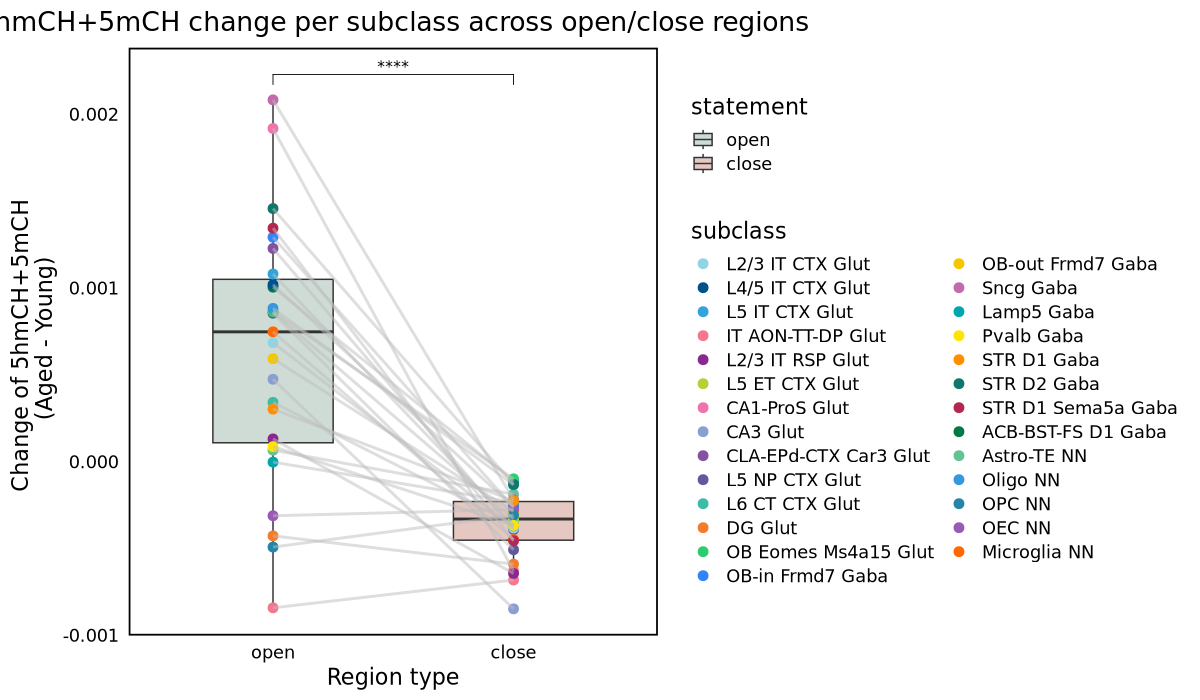

In [53]:
options(repr.plot.width = 12, repr.plot.height = 7, repr.plot.res = 100)
ggplot(mCH_data, aes(x = statement, y = mean_diff)) +
  geom_boxplot(aes(fill = statement), alpha = 0.4, width = 0.5, outlier.shape = NA) +
  geom_point(aes(color = subclass), size = 3) +
  geom_line(aes(group = subclass, color = subclass), size = 1, color = "grey", alpha = 0.5) +
  stat_compare_means(comparisons = my_comparisons, 
                     method = "t.test", 
                     label = "p.signif", 
                     paired = TRUE,
                     tip.length = 0.02,
                     vjust = 0.3) +
  labs(
    x = "Region type",
    y = "Change of 5hmCH+5mCH \n (Aged - Young)",
    title = "5hmCH+5mCH change per subclass across open/close regions"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1.2),
    axis.text = element_text(color = "black"),
    axis.title = element_text(face = "plain"), 
    plot.title = element_text(hjust = 0.5, face = "plain"),
    legend.position = "right"
  ) +
  scale_fill_manual(values = c("open" = "#88A997", "close" = "#BE7767")) +
  scale_color_manual(values = subclass.col)

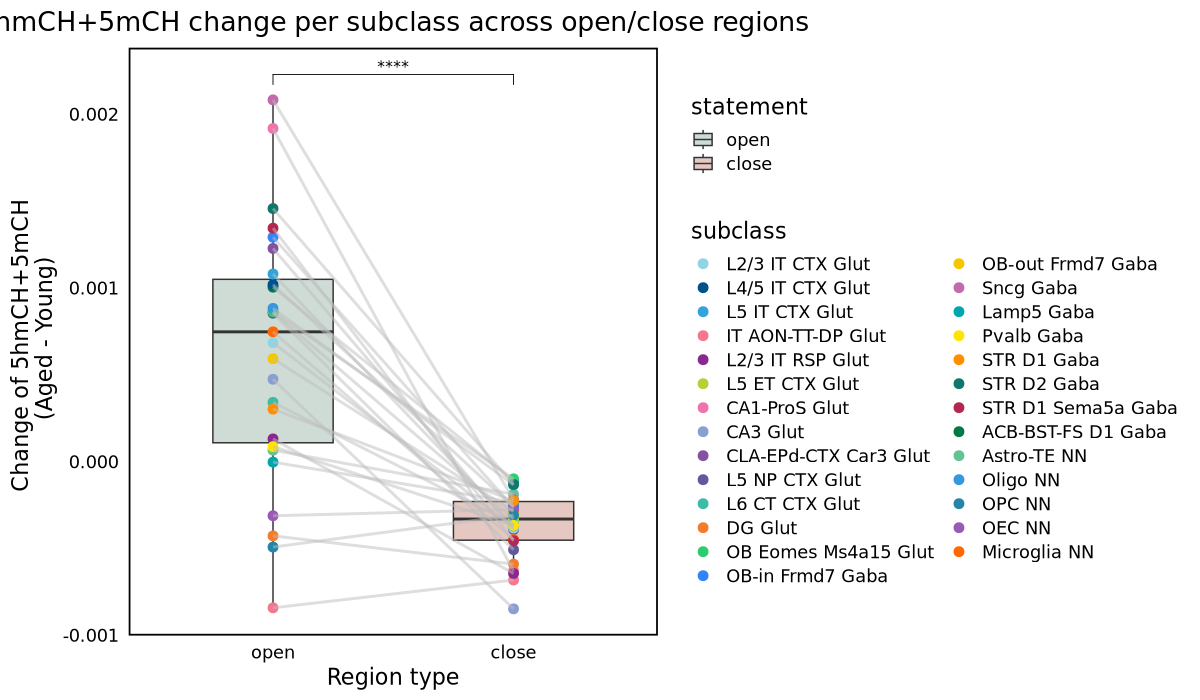

In [54]:
options(repr.plot.width = 12, repr.plot.height = 7, repr.plot.res = 100)
ggplot(mCH_data, aes(x = statement, y = mean_diff)) +
  geom_boxplot(aes(fill = statement), alpha = 0.4, width = 0.5, outlier.shape = NA) +
  geom_point(aes(color = subclass), size = 3) +
  geom_line(aes(group = subclass, color = subclass), size = 1, color = "grey", alpha = 0.5) +
  stat_compare_means(comparisons = my_comparisons, 
                     method = "t.test", 
                     label = "p.signif", 
                     paired = TRUE,
                     tip.length = 0.02,
                     vjust = 0.3) +
  labs(
    x = "Region type",
    y = "Change of 5hmCH+5mCH \n (Aged - Young)",
    title = "5hmCH+5mCH change per subclass across open/close regions"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1.2),
    axis.text = element_text(color = "black"),
    axis.title = element_text(face = "plain"), 
    plot.title = element_text(hjust = 0.5, face = "plain"),
    legend.position = "right"
  ) +
  scale_fill_manual(values = c("open" = "#88A997", "close" = "#BE7767")) +
  scale_color_manual(values = subclass.col)

In [ ]:
pdf(paste0(output,"/02-ATAC_open_close_peak_total5mCH_methylation_ratio_boxplot_including_signif.pdf"),width = 12.,height = 7)
ggplot(mCH_data, aes(x = statement, y = mean_diff)) +
  geom_boxplot(aes(fill = statement), alpha = 0.4, width = 0.5, outlier.shape = NA) +
  geom_point(aes(color = subclass), size = 3) +
  geom_line(aes(group = subclass, color = subclass), size = 1, color = "grey", alpha = 0.5) +
  stat_compare_means(comparisons = my_comparisons, 
                     method = "t.test", 
                     label = "p.signif", 
                     paired = TRUE,
                     tip.length = 0.02,
                     vjust = 0.3) +
  labs(
    x = "Region type",
    y = "Change of 5hmCH+5mCH \n (Aged - Young)",
    title = "5hmCH+5mCH change per subclass across open/close regions"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1.2),
    axis.text = element_text(color = "black"),
    axis.title = element_text(face = "plain"), 
    plot.title = element_text(hjust = 0.5, face = "plain"),
    legend.position = "right"
  ) +
  scale_fill_manual(values = c("open" = "#88A997", "close" = "#BE7767")) +
  scale_color_manual(values = subclass.col)
dev.off()

png 
  2

In [56]:
library(dplyr)

In [ ]:
dir_mCH_open <- paste0(indir,"/01_mCH_open_peak/")
dir_hmCH_open <- paste0(indir,"/01_hmCH_open_peak/")
dir_mCH_close <- paste0(indir,"/01_mCH_close_peak/")
dir_hmCH_close <- paste0(indir,"/01_hmCH_close_peak/")

In [58]:
files_mCH_open <- list.files(dir_mCH_open, pattern = "5mCH\\.mm10\\.tmp$", full.names = TRUE)
files_hmCH_open <- list.files(dir_hmCH_open, pattern = "5hmCH\\.mm10\\.tmp$", full.names = TRUE)
files_mCH_close <- list.files(dir_mCH_close, pattern = "5mCH\\.mm10\\.tmp$", full.names = TRUE)
files_hmCH_close <- list.files(dir_hmCH_close, pattern = "5hmCH\\.mm10\\.tmp$", full.names = TRUE)

In [59]:
files_mCH_open;files_hmCH_open;files_mCH_close;files_hmCH_close

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_open_peak//ACB-BST-FS.D1.Gaba_old_5mCH.mm10.tmp"     
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_open_peak//ACB-BST-FS.D1.Gaba_young_5mCH.mm10.tmp"   
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_open_peak//Astro-TE.NN_old_5mCH.mm10.tmp"            
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_open_peak//Astro-TE.NN_young_5mCH.mm10.tmp"          
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_open_peak//CA1-ProS.Glut_old_5mCH.mm10.tmp"          
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_open_peak//CA1-ProS.Glut_young_5mCH.mm10.tmp"        
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_open_peak//CA3.Glut_old_5mCH.mm10.tmp"               
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_open_peak//CA3.Glut_young_5mCH.mm10.tmp"             
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_open_peak//CLA-EPd-CTX.Car3.Glut_old_5mCH.mm10.tmp"  
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_open_peak//CLA-EPd-CTX.Car3.Glut_young_5mCH.mm10.tmp"
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_open_peak//DG.Glut_old_5mCH.mm10.tmp"                
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_open_peak//DG.Glut_young_5mCH.mm10.tmp"              
[13] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_open_peak//IT.AON-TT-DP.Glut_old_5mCH.mm10.tmp"      
[14] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_open_peak//IT.AON-TT-DP.Glut_young_5mCH.mm10.tmp"    
[15] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_open_peak//L2.3.IT.CTX.Glut_old_5mCH.mm10.tmp"       
[16] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_open_peak//L2.3.IT.CTX.Glut_young_5mCH.mm10.tmp"     
[17] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_open_peak//L2.3.IT.RSP.Glut_old_5mCH.mm10.tmp"       
[18] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_open_peak//L2.3.IT.RSP.Glut_young_5mCH.mm10.tmp"     
[19] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_open_peak//L4.5.IT.CTX.Glut_old_5mCH.mm10.tmp"       
[20] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_open_peak//L4.5.IT.CTX.Glut_young_5mCH.mm10.tmp"     
[21] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_open_peak//L5.ET.CTX.Glut_old_5mCH.mm10.tmp"         
[22] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_open_peak//L5.ET.CTX.Glut_young_5mCH.mm10.tmp"       
[23] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_open_peak//L5.IT.CTX.Glut_old_5mCH.mm10.tmp"         
[24] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_open_peak//L5.IT.CTX.Glut_young_5mCH.mm10.tmp"       
[25] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_open_peak//L5.NP.CTX.Glut_old_5mCH.mm10.tmp"         
[26] "/share/analysisdata/

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_open_peak//ACB-BST-FS.D1.Gaba_old_5hmCH.mm10.tmp"     
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_open_peak//ACB-BST-FS.D1.Gaba_young_5hmCH.mm10.tmp"   
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_open_peak//Astro-TE.NN_old_5hmCH.mm10.tmp"            
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_open_peak//Astro-TE.NN_young_5hmCH.mm10.tmp"          
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_open_peak//CA1-ProS.Glut_old_5hmCH.mm10.tmp"          
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_open_peak//CA1-ProS.Glut_young_5hmCH.mm10.tmp"        
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_open_peak//CA3.Glut_old_5hmCH.mm10.tmp"               
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_open_peak//CA3.Glut_young_5hmCH.mm10.tmp"             
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_open_peak//CLA-EPd-CTX.Car3.Glut_old_5hmCH.mm10.tmp"  
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_open_peak//CLA-EPd-CTX.Car3.Glut_young_5hmCH.mm10.tmp"
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_open_peak//DG.Glut_old_5hmCH.mm10.tmp"                
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_open_peak//DG.Glut_young_5hmCH.mm10.tmp"              
[13] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_open_peak//IT.AON-TT-DP.Glut_old_5hmCH.mm10.tmp"      
[14] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_open_peak//IT.AON-TT-DP.Glut_young_5hmCH.mm10.tmp"    
[15] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_open_peak//L2.3.IT.CTX.Glut_old_5hmCH.mm10.tmp"       
[16] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_open_peak//L2.3.IT.CTX.Glut_young_5hmCH.mm10.tmp"     
[17] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_open_peak//L2.3.IT.RSP.Glut_old_5hmCH.mm10.tmp"       
[18] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_open_peak//L2.3.IT.RSP.Glut_young_5hmCH.mm10.tmp"     
[19] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_open_peak//L4.5.IT.CTX.Glut_old_5hmCH.mm10.tmp"       
[20] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_open_peak//L4.5.IT.CTX.Glut_young_5hmCH.mm10.tmp"     
[21] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_open_peak//L5.ET.CTX.Glut_old_5hmCH.mm10.tmp"         
[22] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_open_peak//L5.ET.CTX.Glut_young_5hmCH.mm10.tmp"       
[23] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_open_peak//L5.IT.CTX.Glut_old_5hmCH.mm10.tmp"         
[24] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_open_peak//L5.IT.CTX.Glut_young_5hmCH.mm10.tmp"       
[25] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_open_peak//L5.NP.CTX.Glut_old_5

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_close_peak//ACB-BST-FS.D1.Gaba_old_5mCH.mm10.tmp"     
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_close_peak//ACB-BST-FS.D1.Gaba_young_5mCH.mm10.tmp"   
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_close_peak//Astro-TE.NN_old_5mCH.mm10.tmp"            
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_close_peak//Astro-TE.NN_young_5mCH.mm10.tmp"          
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_close_peak//CA1-ProS.Glut_old_5mCH.mm10.tmp"          
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_close_peak//CA1-ProS.Glut_young_5mCH.mm10.tmp"        
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_close_peak//CA3.Glut_old_5mCH.mm10.tmp"               
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_close_peak//CA3.Glut_young_5mCH.mm10.tmp"             
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_close_peak//CLA-EPd-CTX.Car3.Glut_old_5mCH.mm10.tmp"  
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_close_peak//CLA-EPd-CTX.Car3.Glut_young_5mCH.mm10.tmp"
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_close_peak//DG.Glut_old_5mCH.mm10.tmp"                
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_close_peak//DG.Glut_young_5mCH.mm10.tmp"              
[13] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_close_peak//IT.AON-TT-DP.Glut_old_5mCH.mm10.tmp"      
[14] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_close_peak//IT.AON-TT-DP.Glut_young_5mCH.mm10.tmp"    
[15] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_close_peak//L2.3.IT.CTX.Glut_old_5mCH.mm10.tmp"       
[16] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_close_peak//L2.3.IT.CTX.Glut_young_5mCH.mm10.tmp"     
[17] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_close_peak//L2.3.IT.RSP.Glut_old_5mCH.mm10.tmp"       
[18] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_close_peak//L2.3.IT.RSP.Glut_young_5mCH.mm10.tmp"     
[19] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_close_peak//L4.5.IT.CTX.Glut_old_5mCH.mm10.tmp"       
[20] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_close_peak//L4.5.IT.CTX.Glut_young_5mCH.mm10.tmp"     
[21] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_close_peak//L5.ET.CTX.Glut_old_5mCH.mm10.tmp"         
[22] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_close_peak//L5.ET.CTX.Glut_young_5mCH.mm10.tmp"       
[23] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_close_peak//L5.IT.CTX.Glut_old_5mCH.mm10.tmp"         
[24] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_close_peak//L5.IT.CTX.Glut_young_5mCH.mm10.tmp"       
[25] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_mCH_close_peak//L5.NP.CTX.Glut_old_5mCH.mm10.tmp"         
[

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_close_peak//ACB-BST-FS.D1.Gaba_old_5hmCH.mm10.tmp"     
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_close_peak//ACB-BST-FS.D1.Gaba_young_5hmCH.mm10.tmp"   
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_close_peak//Astro-TE.NN_old_5hmCH.mm10.tmp"            
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_close_peak//Astro-TE.NN_young_5hmCH.mm10.tmp"          
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_close_peak//CA1-ProS.Glut_old_5hmCH.mm10.tmp"          
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_close_peak//CA1-ProS.Glut_young_5hmCH.mm10.tmp"        
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_close_peak//CA3.Glut_old_5hmCH.mm10.tmp"               
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_close_peak//CA3.Glut_young_5hmCH.mm10.tmp"             
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_close_peak//CLA-EPd-CTX.Car3.Glut_old_5hmCH.mm10.tmp"  
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_close_peak//CLA-EPd-CTX.Car3.Glut_young_5hmCH.mm10.tmp"
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_close_peak//DG.Glut_old_5hmCH.mm10.tmp"                
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_close_peak//DG.Glut_young_5hmCH.mm10.tmp"              
[13] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_close_peak//IT.AON-TT-DP.Glut_old_5hmCH.mm10.tmp"      
[14] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_close_peak//IT.AON-TT-DP.Glut_young_5hmCH.mm10.tmp"    
[15] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_close_peak//L2.3.IT.CTX.Glut_old_5hmCH.mm10.tmp"       
[16] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_close_peak//L2.3.IT.CTX.Glut_young_5hmCH.mm10.tmp"     
[17] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_close_peak//L2.3.IT.RSP.Glut_old_5hmCH.mm10.tmp"       
[18] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_close_peak//L2.3.IT.RSP.Glut_young_5hmCH.mm10.tmp"     
[19] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_close_peak//L4.5.IT.CTX.Glut_old_5hmCH.mm10.tmp"       
[20] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_close_peak//L4.5.IT.CTX.Glut_young_5hmCH.mm10.tmp"     
[21] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_close_peak//L5.ET.CTX.Glut_old_5hmCH.mm10.tmp"         
[22] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_close_peak//L5.ET.CTX.Glut_young_5hmCH.mm10.tmp"       
[23] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_close_peak//L5.IT.CTX.Glut_old_5hmCH.mm10.tmp"         
[24] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_close_peak//L5.IT.CTX.Glut_young_5hmCH.mm10.tmp"       
[25] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250427/output/01_hmCH_close_p

In [60]:
process_files <- function(files1, files2) {
  result_list <- list()
  
  for (file1 in files1) {
    
    file_name <- basename(file1)
    corresponding_file <- files2[grepl(gsub("5mC", "5hmC", file_name), files2)]
    
    if (length(corresponding_file) == 1) {

      data1 <- read.table(file1, header = TRUE, stringsAsFactors = FALSE)
#       print(head(data1))
      data2 <- read.table(corresponding_file, header = TRUE, stringsAsFactors = FALSE)
#       print(head(data2))

      data1 <- data1[!is.na(data1[, 2]), ]
      data2 <- data2[!is.na(data2[, 2]), ]
      common_ids <- intersect(data1[, 1], data2[, 1])
      data1 <- data1[data1[, 1] %in% common_ids, ]
      data2 <- data2[data2[, 1] %in% common_ids, ]
      data1 <- data1[match(common_ids, data1[, 1]), ]
      data2 <- data2[match(common_ids, data2[, 1]), ]

      if (!identical(data1[, 1], data2[, 1])) {
        stop(paste("The first columns of", file1, "and", corresponding_file, "are not identical"))
      }

      diff <- data1[, 2] - data2[, 2]
      diff[diff < 0] <- 0
      avg_diff <- mean(diff, na.rm = TRUE)

      subclass <- gsub("_5mC.*$", "", file_name) %>% gsub("_(old|young)","",.)
      age_group <- ifelse(grepl("young", file_name), "young", "old")

      result_list[[file_name]] <- data.frame(Subclass = subclass,
                                             Age_Group = age_group,
                                             Difference = avg_diff)
    }
  }

  bind_rows(result_list)
}

In [61]:
result_open <- process_files(files_mCH_open, files_hmCH_open)
result_close <- process_files(files_mCH_close, files_hmCH_close)

In [62]:
result_open;result_close

Subclass,Age_Group,Difference
<chr>,<chr>,<dbl>
ACB-BST-FS.D1.Gaba,old,0.022766855
ACB-BST-FS.D1.Gaba,young,0.021995058
Astro-TE.NN,old,0.006147129
Astro-TE.NN,young,0.006002536
CA1-ProS.Glut,old,0.013463750
CA1-ProS.Glut,young,0.011909679
CA3.Glut,old,0.014494213
CA3.Glut,young,0.014344673
CLA-EPd-CTX.Car3.Glut,old,0.018458990


Subclass,Age_Group,Difference
<chr>,<chr>,<dbl>
ACB-BST-FS.D1.Gaba,old,0.004931685
ACB-BST-FS.D1.Gaba,young,0.004949862
Astro-TE.NN,old,0.003004941
Astro-TE.NN,young,0.002957962
CA1-ProS.Glut,old,0.003207287
CA1-ProS.Glut,young,0.003211488
CA3.Glut,old,0.003688584
CA3.Glut,young,0.003581012
CLA-EPd-CTX.Car3.Glut,old,0.004512157


In [63]:
library(tidyr)

In [64]:
final_result <- bind_rows(
  result_open %>% mutate(statement = "open"),
  result_close %>% mutate(statement = "close")
) %>%
  pivot_wider(names_from = Age_Group, values_from = Difference) %>% 
  mutate(Old_Young_Diff = old - young) ## %>%  
#   select(Subclass, Old_Young_Diff) 

In [65]:
final_result

Subclass,statement,old,young,Old_Young_Diff
<chr>,<chr>,<dbl>,<dbl>,<dbl>
ACB-BST-FS.D1.Gaba,open,0.022766855,0.021995058,7.717969e-04
Astro-TE.NN,open,0.006147129,0.006002536,1.445929e-04
CA1-ProS.Glut,open,0.013463750,0.011909679,1.554071e-03
CA3.Glut,open,0.014494213,0.014344673,1.495401e-04
CLA-EPd-CTX.Car3.Glut,open,0.018458990,0.017992534,4.664553e-04
DG.Glut,open,0.004566963,0.004768468,-2.015055e-04
IT.AON-TT-DP.Glut,open,0.015085727,0.016112663,-1.026936e-03
L2.3.IT.CTX.Glut,open,0.015323036,0.015009015,3.140213e-04
L2.3.IT.RSP.Glut,open,0.012197447,0.012204644,-7.197236e-06


In [66]:
unique(final_result$Subclass)

[1] "ACB-BST-FS.D1.Gaba"    "Astro-TE.NN"           "CA1-ProS.Glut"        
 [4] "CA3.Glut"              "CLA-EPd-CTX.Car3.Glut" "DG.Glut"              
 [7] "IT.AON-TT-DP.Glut"     "L2.3.IT.CTX.Glut"      "L2.3.IT.RSP.Glut"     
[10] "L4.5.IT.CTX.Glut"      "L5.ET.CTX.Glut"        "L5.IT.CTX.Glut"       
[13] "L5.NP.CTX.Glut"        "L6.CT.CTX.Glut"        "Lamp5.Gaba"           
[16] "Microglia.NN"          "OB-in.Frmd7.Gaba"      "OB-out.Frmd7.Gaba"    
[19] "OB.Eomes.Ms4a15.Glut"  "OEC.NN"                "Oligo.NN"             
[22] "OPC.NN"                "Pvalb.Gaba"            "Sncg.Gaba"            
[25] "STR.D1.Gaba"           "STR.D1.Sema5a.Gaba"    "STR.D2.Gaba"

In [67]:
subclass_info

subclass_v1,subclass_v2
<chr>,<chr>
ACB-BST-FS.D1.Gaba,ACB-BST-FS D1 Gaba
Astro-TE.NN,Astro-TE NN
CA1-ProS.Glut,CA1-ProS Glut
CA3.Glut,CA3 Glut
CLA-EPd-CTX.Car3.Glut,CLA-EPd-CTX Car3 Glut
DG.Glut,DG Glut
IT.AON-TT-DP.Glut,IT AON-TT-DP Glut
L2.3.IT.CTX.Glut,L2/3 IT CTX Glut
L2.3.IT.RSP.Glut,L2/3 IT RSP Glut


In [68]:
final_result$Subclass <- subclass_info$subclass_v2[match(final_result$Subclass,subclass_info$subclass_v1)]

In [69]:
final_result

Subclass,statement,old,young,Old_Young_Diff
<chr>,<chr>,<dbl>,<dbl>,<dbl>
ACB-BST-FS D1 Gaba,open,0.022766855,0.021995058,7.717969e-04
Astro-TE NN,open,0.006147129,0.006002536,1.445929e-04
CA1-ProS Glut,open,0.013463750,0.011909679,1.554071e-03
CA3 Glut,open,0.014494213,0.014344673,1.495401e-04
CLA-EPd-CTX Car3 Glut,open,0.018458990,0.017992534,4.664553e-04
DG Glut,open,0.004566963,0.004768468,-2.015055e-04
IT AON-TT-DP Glut,open,0.015085727,0.016112663,-1.026936e-03
L2/3 IT CTX Glut,open,0.015323036,0.015009015,3.140213e-04
L2/3 IT RSP Glut,open,0.012197447,0.012204644,-7.197236e-06


In [70]:
final_result$Subclass <- factor(final_result$Subclass,levels = subclass_order)

In [71]:
levels(final_result$Subclass)

[1] "L2/3 IT CTX Glut"      "L4/5 IT CTX Glut"      "L5 IT CTX Glut"       
 [4] "IT AON-TT-DP Glut"     "L2/3 IT RSP Glut"      "L5 ET CTX Glut"       
 [7] "CA1-ProS Glut"         "CA3 Glut"              "CLA-EPd-CTX Car3 Glut"
[10] "L5 NP CTX Glut"        "L6 CT CTX Glut"        "DG Glut"              
[13] "OB Eomes Ms4a15 Glut"  "OB-in Frmd7 Gaba"      "OB-out Frmd7 Gaba"    
[16] "Sncg Gaba"             "Lamp5 Gaba"            "Pvalb Gaba"           
[19] "STR D1 Gaba"           "STR D2 Gaba"           "STR D1 Sema5a Gaba"   
[22] "ACB-BST-FS D1 Gaba"    "Astro-TE NN"           "Oligo NN"             
[25] "OPC NN"                "OEC NN"                "Microglia NN"

In [72]:
final_result$statement <- factor(final_result$statement,levels = c("open","close"))

In [73]:
levels(final_result$statement)

[1] "open"  "close"

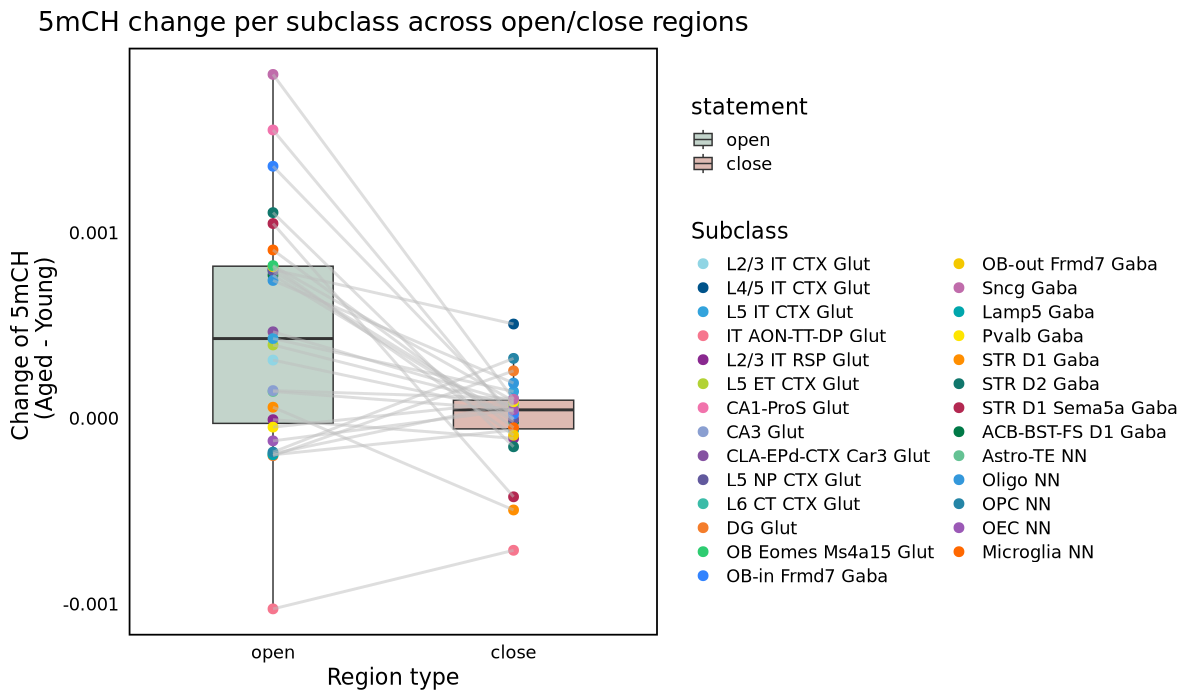

In [74]:
options(repr.plot.width = 12, repr.plot.height = 7, repr.plot.res = 100)
ggplot(final_result, aes(x = statement, y = Old_Young_Diff)) +
  geom_boxplot(aes(fill = statement), alpha = 0.5, width = 0.5, outlier.shape = NA) +
  geom_point(aes(color = Subclass), size = 3) +
  geom_line(aes(group = Subclass, color = Subclass), size = 1, color = "grey", alpha = 0.5) +
  labs(
    x = "Region type",
    y = "Change of 5mCH \n (Aged - Young)",
    title = "5mCH change per subclass across open/close regions"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1.2),
    axis.text = element_text(color = "black"),
    axis.title = element_text(face = "plain"), 
    plot.title = element_text(hjust = 0.5, face = "plain"),
    legend.position = "right"
  ) +
  scale_fill_manual(values = c("open" = "#88A997", "close" = "#BE7767")) +
  scale_color_manual(values = subclass.col)

In [ ]:
pdf(paste0(output,"/02-ATAC_open_close_peak_true5mCH_methylation_ratio_boxplot.pdf"),width = 12.,height = 7)
ggplot(final_result, aes(x = statement, y = Old_Young_Diff)) +
  geom_boxplot(aes(fill = statement), alpha = 0.5, width = 0.5, outlier.shape = NA) +
  geom_point(aes(color = Subclass), size = 3) +
  geom_line(aes(group = Subclass, color = Subclass), size = 1, color = "grey", alpha = 0.5) +
  labs(
    x = "Region type",
    y = "Change of 5mCH \n (Aged - Young)",
    title = "5mCH change per subclass across open/close regions"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1.2),
    axis.text = element_text(color = "black"),
    axis.title = element_text(face = "plain"), 
    plot.title = element_text(hjust = 0.5, face = "plain"),
    legend.position = "right"
  ) +
  scale_fill_manual(values = c("open" = "#88A997", "close" = "#BE7767")) +
  scale_color_manual(values = subclass.col)
dev.off()

png 
  2

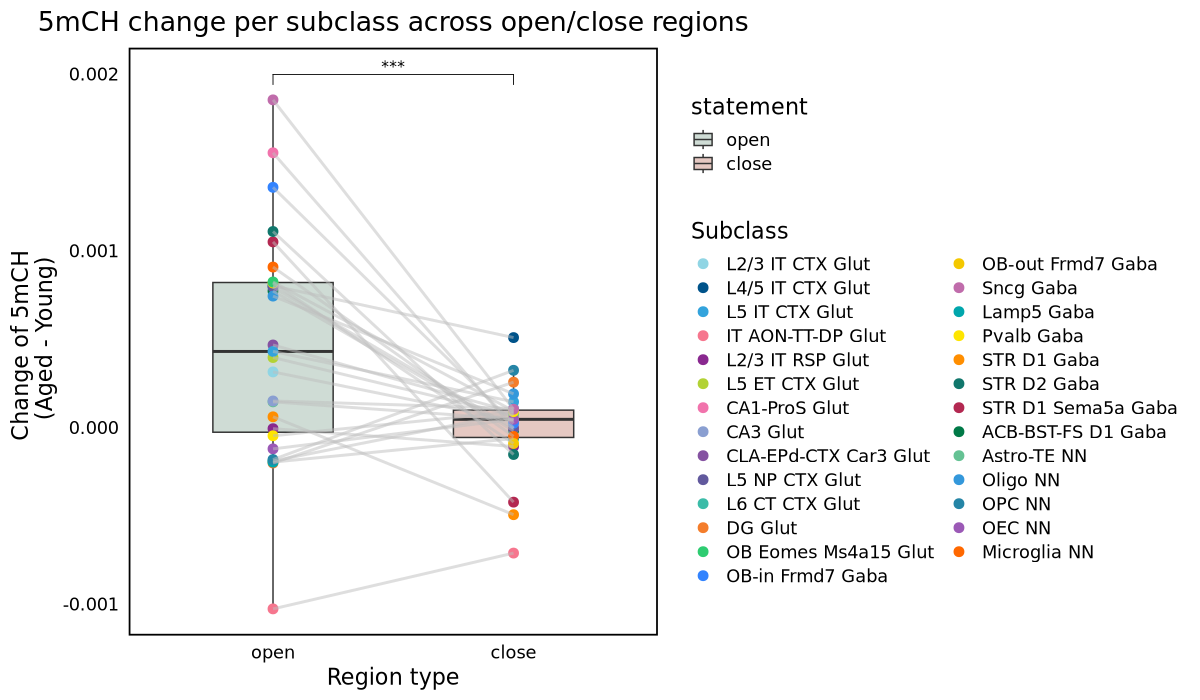

In [76]:
options(repr.plot.width = 12, repr.plot.height = 7, repr.plot.res = 100)
ggplot(final_result, aes(x = statement, y = Old_Young_Diff)) +
  geom_boxplot(aes(fill = statement), alpha = 0.4, width = 0.5, outlier.shape = NA) +
  geom_point(aes(color = Subclass), size = 3) +
  geom_line(aes(group = Subclass, color = Subclass), size = 1, color = "grey", alpha = 0.5) +
  stat_compare_means(comparisons = my_comparisons, 
                     method = "t.test", 
                     label = "p.signif", 
                     paired = TRUE,
                     tip.length = 0.02,
                     vjust = 0.3) +
  labs(
    x = "Region type",
    y = "Change of 5mCH \n (Aged - Young)",
    title = "5mCH change per subclass across open/close regions"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1.2),
    axis.text = element_text(color = "black"),
    axis.title = element_text(face = "plain"), 
    plot.title = element_text(hjust = 0.5, face = "plain"),
    legend.position = "right"
  ) +
  scale_fill_manual(values = c("open" = "#88A997", "close" = "#BE7767")) +
  scale_color_manual(values = subclass.col)

In [ ]:
pdf(paste0(output,"/02-ATAC_open_close_peak_true5mCH_methylation_ratio_boxplot_signif.pdf"),width = 12.,height = 7)
ggplot(final_result, aes(x = statement, y = Old_Young_Diff)) +
  geom_boxplot(aes(fill = statement), alpha = 0.4, width = 0.5, outlier.shape = NA) +
  geom_point(aes(color = Subclass), size = 3) +
  geom_line(aes(group = Subclass, color = Subclass), size = 1, color = "grey", alpha = 0.5) +
  stat_compare_means(comparisons = my_comparisons, 
                     method = "t.test", 
                     label = "p.signif", 
                     paired = TRUE,
                     tip.length = 0.02,
                     vjust = 0.3) +
  labs(
    x = "Region type",
    y = "Change of 5mCH \n (Aged - Young)",
    title = "5mCH change per subclass across open/close regions"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1.2),
    axis.text = element_text(color = "black"),
    axis.title = element_text(face = "plain"), 
    plot.title = element_text(hjust = 0.5, face = "plain"),
    legend.position = "right"
  ) +
  scale_fill_manual(values = c("open" = "#88A997", "close" = "#BE7767")) +
  scale_color_manual(values = subclass.col)
dev.off()

png 
  2

In [78]:
table(names(subclass.col) %in% final_result$Subclass)


TRUE 
  27 

In [79]:
unique(final_result$Subclass)

[1] ACB-BST-FS D1 Gaba    Astro-TE NN           CA1-ProS Glut        
 [4] CA3 Glut              CLA-EPd-CTX Car3 Glut DG Glut              
 [7] IT AON-TT-DP Glut     L2/3 IT CTX Glut      L2/3 IT RSP Glut     
[10] L4/5 IT CTX Glut      L5 ET CTX Glut        L5 IT CTX Glut       
[13] L5 NP CTX Glut        L6 CT CTX Glut        Lamp5 Gaba           
[16] Microglia NN          OB-in Frmd7 Gaba      OB-out Frmd7 Gaba    
[19] OB Eomes Ms4a15 Glut  OEC NN                Oligo NN             
[22] OPC NN                Pvalb Gaba            Sncg Gaba            
[25] STR D1 Gaba           STR D1 Sema5a Gaba    STR D2 Gaba          
27 Levels: L2/3 IT CTX Glut L4/5 IT CTX Glut ... Microglia NN